In [ ]:
!pip install simpy

--- Airport Simulation ---
[000.23] Customer 1 arrived at the airport.
[000.23] Customer 1 started arrived at the airport (Waited: 0.00 mins). 
[001.11] Customer 1 finished waiting and departed.
[001.74] Customer 2 arrived at the airport.
[001.74] Customer 2 started arrived at the airport (Waited: 0.00 mins). 
[001.85] Customer 2 finished waiting and departed.
[002.20] Customer 3 arrived at the airport.
[002.20] Customer 3 started arrived at the airport (Waited: 0.00 mins). 
[002.24] Customer 3 finished waiting and departed.
[002.28] Customer 4 arrived at the airport.
[002.28] Customer 4 started arrived at the airport (Waited: 0.00 mins). 
[002.89] Customer 4 finished waiting and departed.
[003.29] Customer 5 arrived at the airport.
[003.29] Customer 5 started arrived at the airport (Waited: 0.00 mins). 
[003.30] Customer 5 finished waiting and departed.
[003.90] Customer 6 arrived at the airport.
[003.90] Customer 6 started arrived at the airport (Waited: 0.00 mins). 
[005.09] Custome

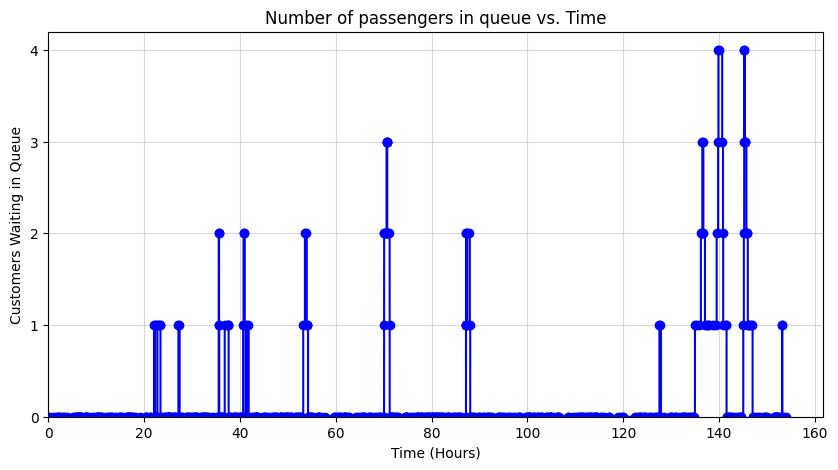

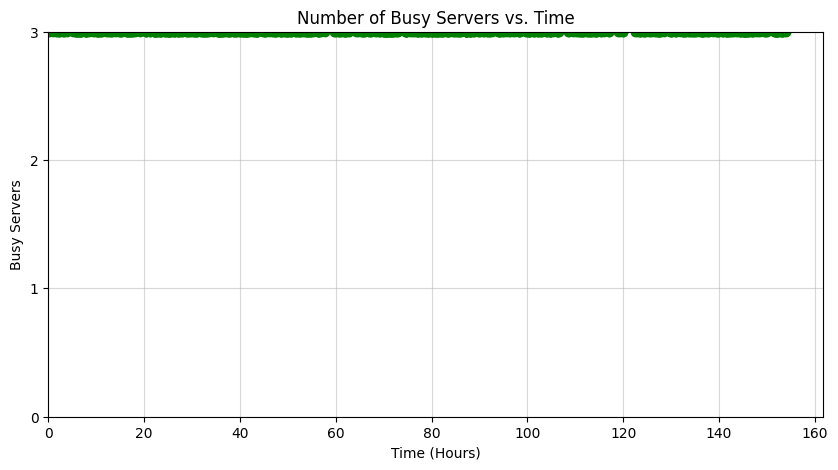

In [ ]:
# @title Azad: Base Situation
!pip install simpy
import simpy
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Simulation Parameters ---
N_CUSTOMERS = 300
N_SERVERS = 3
RANDOM_SEED = 42
INTERARRIVAL_TIME = 30.0  # Average time between arrivals
SERVICE_TIME = 40.0       # Average time to wait before departure
#SIM_TIME = 500           # Total minutes to simulate

# We will use these lists to collect data for analysis later!
wait_times = []
queue_times = [0.0]
queue_lengths = [0]

# Helper to record queue state as it changes

def record_queue_state(time, length):
    if queue_times and queue_times[-1] == time:
        queue_lengths[-1] = length
    else:
        queue_times.append(time)
        queue_lengths.append(length)

# --- 2. Defining the Processes ---

def customer(env, name, atm):
    """Models a single passenger waiting at the airport."""
    arrival_time = env.now
    print(f"[{arrival_time/60:06.2f}] {name} arrived at the airport.")

    # Request the Counter (This automatically adds the customer to the queue if it's busy)
    request = atm.request()
    record_queue_state(env.now, len(atm.queue))

    with request:
        # Pause the passenger until it's their turn
        yield request

        # Calculate how long they waited
        wait_time = env.now - arrival_time
        wait_times.append(wait_time)
        print(f"[{env.now/60:06.2f}] {name} started arrived at the airport (Waited: {wait_time:.2f} mins). ")

        # Simulate the time it takes to wait
        # We use an exponential distribution for randomness
        time_at_airport = np.random.exponential(SERVICE_TIME)
        yield env.timeout(time_at_airport)

    # Record queue length after service completion and resource release
    record_queue_state(env.now, len(atm.queue))
    print(f"[{env.now/60:06.2f}] {name} finished waiting and departed.")

def customer_generator(env, atm):
    """Generates new customers up to N_CUSTOMERS."""
    customer_id = 1
    for _ in range(N_CUSTOMERS):
        # Determine the time until the NEXT customer arrives
        time_until_next = np.random.exponential(INTERARRIVAL_TIME)

        # Pause the generator until that time passes
        yield env.timeout(time_until_next)

        # Create a new customer process
        env.process(customer(env, f"Customer {customer_id}", atm))
        customer_id += 1

# --- 3. Running the Simulation ---
print("--- Airport Simulation ---")

# Set the random seed so our results are reproducible
np.random.seed(RANDOM_SEED)

# Create the environment and the single-server resource
env = simpy.Environment()
airport = simpy.Resource(env, capacity=N_SERVERS)

# Start the generator
env.process(customer_generator(env, airport))

# Run the simulation until all generated customer processes are complete
env.run()

print("\n--- Simulation Complete ---")

# 1. Calculate basic statistics
average_wait = np.mean(wait_times)
max_wait = np.max(wait_times)
total_passengers = len(wait_times)

print(f"Total passengers served: {total_passengers}")
print(f"Average wait time: {average_wait:.2f} minutes")
print(f"Maximum wait time: {max_wait:.2f} minutes")

# 2. Visualize the queue length over time
queue_hours = [t / 60 for t in queue_times]
plt.figure(figsize=(10, 5))
plt.step(queue_hours, queue_lengths, where='post', marker='o', color='b')
plt.yticks(range(0, max(queue_lengths) + 1))
plt.title("Number of passengers in queue vs. Time")
plt.xlabel("Time (Hours)")
plt.ylabel("Customers Waiting in Queue")
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.grid(True, alpha=0.5)
plt.show()

# 3. Visualize busy servers over time
busy_servers = [N_SERVERS - len(atm.queue) for atm in [airport] * len(queue_times)]
plt.figure(figsize=(10, 5))
plt.step(queue_hours, busy_servers, where='post', marker='o', color='g')
plt.yticks(range(0, max(queue_lengths) + 1))
plt.title("Number of Busy Servers vs. Time")
plt.xlabel("Time (Hours)")
plt.ylabel("Busy Servers")
plt.ylim(bottom=0, top=N_SERVERS)
plt.xlim(left=0)
plt.grid(True, alpha=0.5)
plt.show()

---Airport Simulation Starting ---
--- Simulation Complete ---

Total passengers served : 300
Simulation duration     : 9240.66 min (154.01 hrs)
Average wait time       : 3.04 min
Maximum wait time       : 69.27 min
Server utilisation      : 44.86%
Throughput              : 1.95 customers/hr
Total system cost       : RM 14043.64


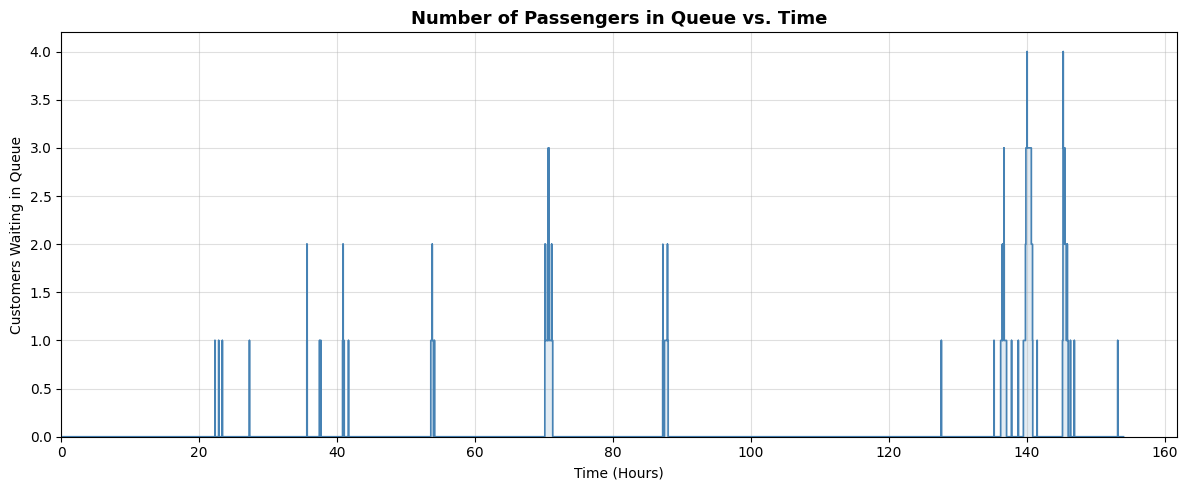

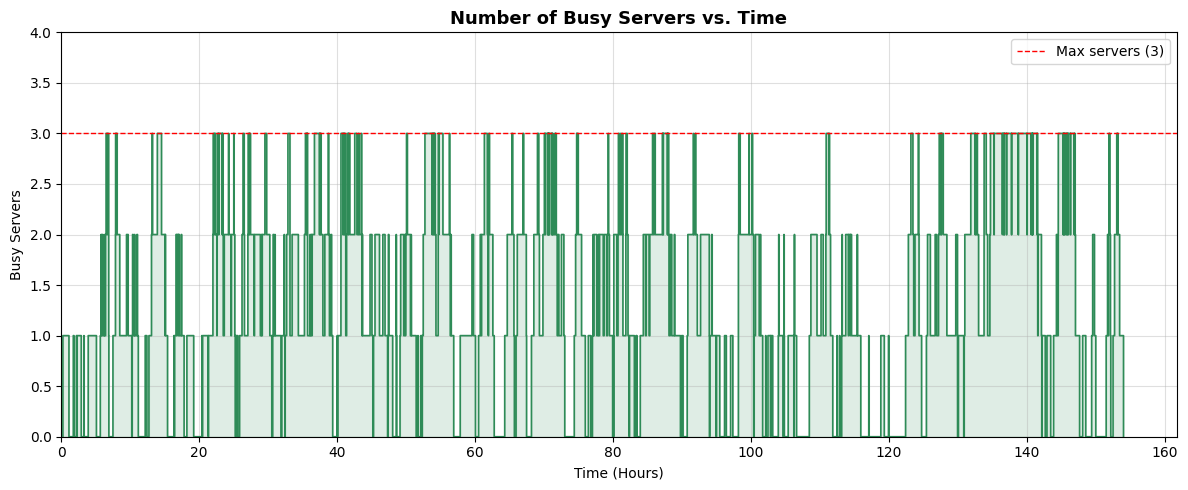


Excel file saved: Airport_Simulation_Timestamps.xlsx
Sheets: ['Event Log', 'Timeline', 'Summary & Cost', 'Parameters']
Event log rows: 300
Timeline rows : 600


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title Adriana: Event Trace (Spread Sheet)
!pip install simpy
import simpy
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from datetime import datetime

# ─── Parameters ───────────────────────────────────────────────────────────────
N_CUSTOMERS       = 300
N_SERVERS         = 3
RANDOM_SEED       = 42
INTERARRIVAL_TIME = 30.0   # minutes (exponential mean)
SERVICE_TIME      = 40.0   # minutes (exponential mean)

SERVER_COST_PER_MIN  = 0.50   # RM per server per minute
WAIT_PENALTY_PER_MIN = 0.20   # RM per minute a customer waits

# ─── Shared data stores ───────────────────────────────────────────────────────
event_log       = []
queue_timeline  = []
server_timeline = []

def log_timeline(env, airport):
    q_len = len(airport.queue)
    busy  = airport.count
    queue_timeline.append((round(env.now, 4), q_len))
    server_timeline.append((round(env.now, 4), busy))

# ─── SimPy processes ──────────────────────────────────────────────────────────
def customer(env, name, cid, airport):
    arrival_time = env.now
    log_timeline(env, airport)

    with airport.request() as req:
        yield req
        service_start = env.now
        wait_time     = service_start - arrival_time
        log_timeline(env, airport)

        service_duration = np.random.exponential(SERVICE_TIME)
        yield env.timeout(service_duration)

    departure_time = env.now
    log_timeline(env, airport)

    event_log.append({
        "Customer ID"               : cid,
        "Arrival Time (min)"        : round(arrival_time, 4),
        "Service Start (min)"       : round(service_start, 4),
        "Wait Time (min)"           : round(wait_time, 4),
        "Service Duration (min)"    : round(service_duration, 4),
        "Departure Time (min)"      : round(departure_time, 4),
        "Total Time in System (min)": round(departure_time - arrival_time, 4),
    })

def customer_generator(env, airport):
    for cid in range(1, N_CUSTOMERS + 1):
        yield env.timeout(np.random.exponential(INTERARRIVAL_TIME))
        env.process(customer(env, f"Customer {cid}", cid, airport))

# ─── Run simulation ───────────────────────────────────────────────────────────
print("---Airport Simulation Starting ---")
np.random.seed(RANDOM_SEED)
env     = simpy.Environment()
airport = simpy.Resource(env, capacity=N_SERVERS)
env.process(customer_generator(env, airport))
env.run()
print("--- Simulation Complete ---\n")

# ─── Compute summary metrics ──────────────────────────────────────────────────
wait_times   = [r["Wait Time (min)"] for r in event_log]
total_times  = [r["Total Time in System (min)"] for r in event_log]
sim_duration = max(r["Departure Time (min)"] for r in event_log)

avg_wait      = np.mean(wait_times)
max_wait      = np.max(wait_times)
avg_total     = np.mean(total_times)
throughput_hr = len(event_log) / (sim_duration / 60)
peak_queue    = max(q for _, q in queue_timeline)
arrival_rate  = N_CUSTOMERS / sim_duration
avg_queue_len = arrival_rate * avg_wait
total_service = sum(r["Service Duration (min)"] for r in event_log)
utilisation   = total_service / (N_SERVERS * sim_duration) * 100
server_cost   = N_SERVERS * SERVER_COST_PER_MIN * sim_duration
wait_cost     = sum(wait_times) * WAIT_PENALTY_PER_MIN
total_cost    = server_cost + wait_cost

print(f"Total passengers served : {len(event_log)}")
print(f"Simulation duration     : {sim_duration:.2f} min ({sim_duration/60:.2f} hrs)")
print(f"Average wait time       : {avg_wait:.2f} min")
print(f"Maximum wait time       : {max_wait:.2f} min")
print(f"Server utilisation      : {utilisation:.2f}%")
print(f"Throughput              : {throughput_hr:.2f} customers/hr")
print(f"Total system cost       : RM {total_cost:.2f}")

# ─── Graphs ───────────────────────────────────────────────────────────────────
queue_hours  = [t / 60 for t, _ in queue_timeline]
queue_lens   = [q for _, q in queue_timeline]
server_hours = [t / 60 for t, _ in server_timeline]
server_busy  = [s for _, s in server_timeline]

plt.figure(figsize=(12, 5))
plt.step(queue_hours, queue_lens, where='post', color='steelblue', linewidth=1.2)
plt.fill_between(queue_hours, queue_lens, step='post', alpha=0.15, color='steelblue')
plt.title("Number of Passengers in Queue vs. Time", fontsize=13, fontweight='bold')
plt.xlabel("Time (Hours)")
plt.ylabel("Customers Waiting in Queue")
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.step(server_hours, server_busy, where='post', color='seagreen', linewidth=1.2)
plt.fill_between(server_hours, server_busy, step='post', alpha=0.15, color='seagreen')
plt.axhline(y=N_SERVERS, color='red', linestyle='--', linewidth=1, label=f'Max servers ({N_SERVERS})')
plt.title("Number of Busy Servers vs. Time", fontsize=13, fontweight='bold')
plt.xlabel("Time (Hours)")
plt.ylabel("Busy Servers")
plt.ylim(bottom=0, top=N_SERVERS + 1)
plt.xlim(left=0)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# ─── Build Excel workbook ─────────────────────────────────────────────────────
wb = openpyxl.Workbook()

# Style helpers
BLUE_DARK  = "1F4E79"
BLUE_MID   = "2E75B6"
BLUE_LIGHT = "D6E4F0"
BLUE_ALT   = "EBF3FB"
WHITE      = "FFFFFF"
YELLOW_HL  = "FFF2CC"

thin = Side(style="thin", color="AAAAAA")
box  = Border(left=thin, right=thin, top=thin, bottom=thin)

def hdr_cell(ws, row, col, value, bg=BLUE_DARK, fg=WHITE, bold=True, wrap=False, align="center"):
    c = ws.cell(row=row, column=col, value=value)
    c.font      = Font(name="Arial", bold=bold, color=fg, size=10)
    c.fill      = PatternFill("solid", fgColor=bg)
    c.alignment = Alignment(horizontal=align, vertical="center", wrap_text=wrap)
    c.border    = box
    return c

def data_cell(ws, row, col, value, bg=WHITE, number_format=None, bold=False, align="center"):
    c = ws.cell(row=row, column=col, value=value)
    c.font      = Font(name="Arial", size=10, bold=bold)
    c.fill      = PatternFill("solid", fgColor=bg)
    c.alignment = Alignment(horizontal=align, vertical="center")
    c.border    = box
    if number_format:
        c.number_format = number_format
    return c

def set_col_widths(ws, widths):
    for i, w in enumerate(widths, start=1):
        ws.column_dimensions[get_column_letter(i)].width = w

# ── Sheet 1: Event Log ────────────────────────────────────────────────────────
ws1 = wb.active
ws1.title = "Event Log"

ws1.merge_cells("A1:H1")
c = ws1.cell(row=1, column=1, value="AIRPORT SIMULATION — FULL EVENT LOG (300 Customers)")
c.font      = Font(name="Arial", bold=True, size=13, color=WHITE)
c.fill      = PatternFill("solid", fgColor=BLUE_DARK)
c.alignment = Alignment(horizontal="center", vertical="center")
ws1.row_dimensions[1].height = 28

ws1.merge_cells("A2:H2")
c2 = ws1.cell(row=2, column=1,
    value=f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}  |  "
          f"Seed: {RANDOM_SEED}  |  Servers: {N_SERVERS}  |  "
          f"Mean IAT: {INTERARRIVAL_TIME} min  |  Mean Service: {SERVICE_TIME} min")
c2.font      = Font(name="Arial", size=9, color="555555")
c2.fill      = PatternFill("solid", fgColor=BLUE_LIGHT)
c2.alignment = Alignment(horizontal="center")

headers = [
    "Customer ID", "Arrival Time\n(min)", "Service Start\n(min)",
    "Wait Time\n(min)", "Service Duration\n(min)", "Departure Time\n(min)",
    "Total Time in\nSystem (min)", "Waited?"
]
for col, h in enumerate(headers, start=1):
    hdr_cell(ws1, 3, col, h, wrap=True)
ws1.row_dimensions[3].height = 30

for i, row in enumerate(event_log):
    r      = i + 4
    bg     = BLUE_ALT if i % 2 == 0 else WHITE
    waited = row["Wait Time (min)"] > 0

    data_cell(ws1, r, 1, row["Customer ID"],                  bg=bg, align="center")
    data_cell(ws1, r, 2, row["Arrival Time (min)"],           bg=bg, number_format="0.0000")
    data_cell(ws1, r, 3, row["Service Start (min)"],          bg=bg, number_format="0.0000")

    c_wait = data_cell(ws1, r, 4, row["Wait Time (min)"],
                       bg=YELLOW_HL if waited else bg, number_format="0.0000")
    if waited:
        c_wait.font = Font(name="Arial", size=10, color="C00000")

    data_cell(ws1, r, 5, row["Service Duration (min)"],       bg=bg, number_format="0.0000")
    data_cell(ws1, r, 6, row["Departure Time (min)"],         bg=bg, number_format="0.0000")
    data_cell(ws1, r, 7, row["Total Time in System (min)"],   bg=bg, number_format="0.0000")
    data_cell(ws1, r, 8, "YES" if waited else "no",
              bg=YELLOW_HL if waited else bg, bold=waited, align="center")

# Totals row
tot_row = N_CUSTOMERS + 4
hdr_cell(ws1, tot_row, 1, "TOTALS / AVERAGES", bg=BLUE_MID, align="left")
formulas = [
    f"=AVERAGE(B4:B{tot_row-1})",
    f"=AVERAGE(C4:C{tot_row-1})",
    f"=AVERAGE(D4:D{tot_row-1})",
    f"=AVERAGE(E4:E{tot_row-1})",
    f"=MAX(F4:F{tot_row-1})",
    f"=AVERAGE(G4:G{tot_row-1})",
    f'=COUNTIF(H4:H{tot_row-1},"YES")',
]
for ci, formula in enumerate(formulas, start=2):
    c = ws1.cell(tot_row, ci, value=formula)
    c.font      = Font(name="Arial", bold=True, size=10, color=WHITE)
    c.fill      = PatternFill("solid", fgColor=BLUE_MID)
    c.border    = box
    c.alignment = Alignment(horizontal="center", vertical="center")
    if ci < 9:
        c.number_format = "0.0000"

set_col_widths(ws1, [13, 16, 18, 16, 20, 18, 22, 10])
ws1.freeze_panes = "A4"

# ── Sheet 2: Timeline ─────────────────────────────────────────────────────────
ws2 = wb.create_sheet("Timeline")

ws2.merge_cells("A1:D1")
c = ws2.cell(row=1, column=1, value="SIMULATION TIMELINE — Queue & Server State at Every Event")
c.font      = Font(name="Arial", bold=True, size=13, color=WHITE)
c.fill      = PatternFill("solid", fgColor=BLUE_DARK)
c.alignment = Alignment(horizontal="center", vertical="center")
ws2.row_dimensions[1].height = 28

for col, h in enumerate(["Time (min)", "Time (hours)", "Queue Length", "Busy Servers"], start=1):
    hdr_cell(ws2, 2, col, h)

time_map = {}
for t, q in queue_timeline:
    time_map.setdefault(t, {})["queue"] = q
for t, s in server_timeline:
    time_map.setdefault(t, {})["servers"] = s

for i, t in enumerate(sorted(time_map.keys())):
    r  = i + 3
    bg = BLUE_ALT if i % 2 == 0 else WHITE
    data_cell(ws2, r, 1, t,                               bg=bg, number_format="0.0000")
    data_cell(ws2, r, 2, round(t / 60, 6),                bg=bg, number_format="0.000000")
    data_cell(ws2, r, 3, time_map[t].get("queue", ""),    bg=bg)
    data_cell(ws2, r, 4, time_map[t].get("servers", ""),  bg=bg)

set_col_widths(ws2, [14, 14, 14, 14])
ws2.freeze_panes = "A3"

# ── Sheet 3: Summary & Cost ───────────────────────────────────────────────────
ws3 = wb.create_sheet("Summary & Cost")

ws3.merge_cells("A1:C1")
c = ws3.cell(row=1, column=1, value="SIMULATION SUMMARY — Base Model Metrics & Cost Analysis")
c.font      = Font(name="Arial", bold=True, size=13, color=WHITE)
c.fill      = PatternFill("solid", fgColor=BLUE_DARK)
c.alignment = Alignment(horizontal="center", vertical="center")
ws3.row_dimensions[1].height = 28

sections = [
    ("OPERATIONAL METRICS", [
        ("Total Customers Served",    N_CUSTOMERS,               "0"),
        ("Simulation Duration (min)", round(sim_duration, 2),    "0.00"),
        ("Simulation Duration (hrs)", round(sim_duration/60, 2), "0.00"),
        ("Server Utilisation (%)",    round(utilisation, 2),     "0.00"),
        ("Probability Servers Idle (%)", round(100-utilisation, 2), "0.00"),
        ("Throughput (customers/hr)", round(throughput_hr, 2),   "0.00"),
    ]),
    ("WAITING & QUEUE METRICS", [
        ("Average Wait Time (min)",   round(avg_wait, 4),        "0.0000"),
        ("Maximum Wait Time (min)",   round(max_wait, 4),        "0.0000"),
        ("Avg Queue Length (Lq)",     round(avg_queue_len, 4),   "0.0000"),
        ("Peak Queue Length",         peak_queue,                "0"),
        ("Avg Total Time in System",  round(avg_total, 4),       "0.0000"),
    ]),
    ("COST ANALYSIS", [
        ("Server Cost/min (each)",    SERVER_COST_PER_MIN,       "0.00"),
        ("Wait Penalty/min",          WAIT_PENALTY_PER_MIN,      "0.00"),
        ("Server Operating Cost (RM)",round(server_cost, 2),     "0.00"),
        ("Customer Waiting Cost (RM)",round(wait_cost, 2),       "0.00"),
        ("TOTAL SYSTEM COST (RM)",    round(total_cost, 2),      "0.00"),
    ]),
]

current_row = 3
for section_title, rows in sections:
    ws3.merge_cells(f"A{current_row}:C{current_row}")
    hdr_cell(ws3, current_row, 1, section_title, bg=BLUE_MID, align="left")
    ws3.row_dimensions[current_row].height = 20
    current_row += 1
    for i, (label, value, fmt) in enumerate(rows):
        bg   = BLUE_ALT if i % 2 == 0 else WHITE
        bold = "TOTAL" in label
        bg   = YELLOW_HL if bold else bg
        data_cell(ws3, current_row, 1, label, bg=bg, align="left", bold=bold)
        data_cell(ws3, current_row, 2, value, bg=bg, number_format=fmt, bold=bold)
        current_row += 1
    current_row += 1

set_col_widths(ws3, [32, 20, 10])

# ── Sheet 4: Parameters ───────────────────────────────────────────────────────
ws4 = wb.create_sheet("Parameters")

ws4.merge_cells("A1:C1")
c = ws4.cell(row=1, column=1, value="SIMULATION PARAMETERS & ASSUMPTIONS")
c.font      = Font(name="Arial", bold=True, size=13, color=WHITE)
c.fill      = PatternFill("solid", fgColor=BLUE_DARK)
c.alignment = Alignment(horizontal="center", vertical="center")
ws4.row_dimensions[1].height = 28

params = [
    ("SIMULATION SETUP",),
    ("Parameter", "Value", "Notes"),
    ("Number of Customers",    N_CUSTOMERS,             "Fixed per assignment requirement"),
    ("Number of Servers",      N_SERVERS,               "3 parallel service counters"),
    ("Random Seed",            RANDOM_SEED,             "Ensures reproducibility"),
    ("",),
    ("ARRIVAL PROCESS",),
    ("Parameter", "Value", "Notes"),
    ("Inter-Arrival Distribution", "Exponential",       "Memoryless Poisson arrivals"),
    ("Mean Inter-Arrival Time",    f"{INTERARRIVAL_TIME} min", f"λ = {1/INTERARRIVAL_TIME:.4f} customers/min"),
    ("",),
    ("SERVICE PROCESS",),
    ("Parameter", "Value", "Notes"),
    ("Service Distribution",   "Exponential",           "Variable treatment time"),
    ("Mean Service Time",      f"{SERVICE_TIME} min",   f"μ = {1/SERVICE_TIME:.4f} customers/min per server"),
    ("Queue Discipline",       "FCFS",                  "First-Come-First-Served"),
    ("Max Queue Capacity",     "Unlimited",             "No customer abandonment"),
    ("",),
    ("COST MODEL",),
    ("Parameter", "Value", "Notes"),
    ("Server Cost per Min",    f"RM {SERVER_COST_PER_MIN}",  "Per server, per minute"),
    ("Wait Penalty per Min",   f"RM {WAIT_PENALTY_PER_MIN}", "Per minute a customer waits"),
    ("Cost Formula",           "Total = (Servers x Cost x Duration) + (Total Wait x Penalty)", ""),
]

current_row = 2
for row_data in params:
    if len(row_data) == 1:
        if row_data[0]:
            ws4.merge_cells(f"A{current_row}:C{current_row}")
            hdr_cell(ws4, current_row, 1, row_data[0], bg=BLUE_MID, align="left")
        current_row += 1
        continue
    if row_data[0] == "Parameter":
        for ci, h in enumerate(row_data, start=1):
            hdr_cell(ws4, current_row, ci, h, bg="3A6EA0")
    else:
        for ci, val in enumerate(row_data, start=1):
            bg = BLUE_ALT if current_row % 2 == 0 else WHITE
            data_cell(ws4, current_row, ci, val, bg=bg,
                      align="left" if ci in (1, 3) else "center")
    current_row += 1

set_col_widths(ws4, [28, 20, 45])

# ─── Save & Download ──────────────────────────────────────────────────────────
out_path = "Airport_Simulation_Timestamps.xlsx"
wb.save(out_path)
print(f"\nExcel file saved: {out_path}")
print(f"Sheets: {wb.sheetnames}")
print(f"Event log rows: {len(event_log)}")
print(f"Timeline rows : {len(time_map)}")

# Auto-download in Google Colab
from google.colab import files
files.download(out_path)


Simulation Duration     : 9240.66 min (154.01 hrs)
Server Utilisation      : 43.29%
P(Servers Idle)         : 56.71%
Average Wait Time       : 3.0442 min
Maximum Wait Time       : 69.2707 min
Average Queue Length Lq : 0.0988
Peak Customers Waited   : 48
Avg Time in System      : 43.0442 min
Throughput              : 1.95 customers/hr
Server Operating Cost   : RM 13860.99
Wait Penalty Cost       : RM 182.65
Total System Cost       : RM 14043.64


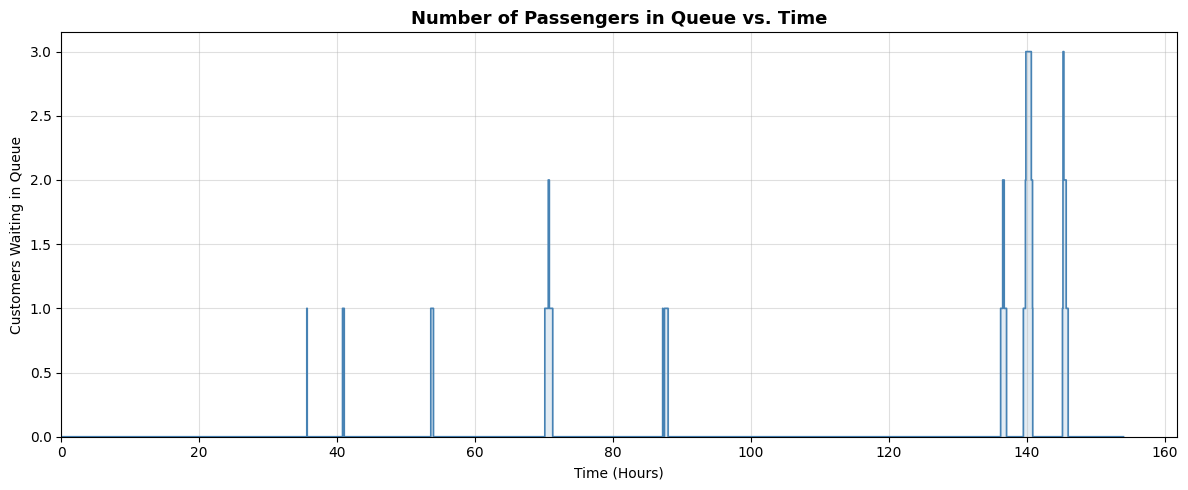

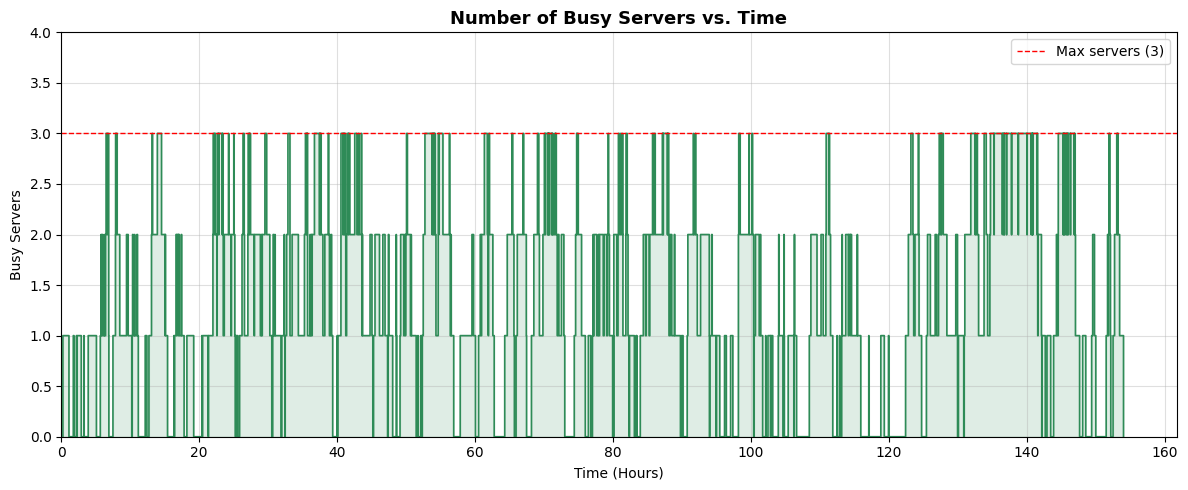

In [ ]:
# @title Adriana: Base Metrics & Base Cost
!pip install simpy

import simpy

import numpy as np

import matplotlib.pyplot as plt



# ─── Parameters ───────────────────────────────────────────────────────────────

N_CUSTOMERS       = 300

N_SERVERS         = 3

RANDOM_SEED       = 42

INTERARRIVAL_TIME = 30.0   # minutes (exponential mean)

SERVICE_TIME      = 40.0   # minutes (exponential mean)



SERVER_COST_PER_MIN  = 0.50   # RM per server per minute

WAIT_PENALTY_PER_MIN = 0.20   # RM per minute a customer waits



# ─── Shared data stores ───────────────────────────────────────────────────────

wait_times   = []

queue_times  = [0.0]

queue_lengths = [0]

server_busy_log = []   # (time, busy_count)



def record_queue(env, airport):

    t   = env.now

    ql  = len(airport.queue)

    bus = airport.count

    if queue_times and queue_times[-1] == t:

        queue_lengths[-1] = ql

    else:

        queue_times.append(t)

        queue_lengths.append(ql)

    server_busy_log.append((t, bus))



# ─── Customer process ─────────────────────────────────────────────────────────

def customer(env, name, airport):

    arrival = env.now

    record_queue(env, airport)



    with airport.request() as req:

        yield req

        wait = env.now - arrival

        wait_times.append(wait)

        record_queue(env, airport)



        service_time = np.random.exponential(SERVICE_TIME)

        yield env.timeout(service_time)



    record_queue(env, airport)



def customer_generator(env, airport):

    for cid in range(1, N_CUSTOMERS + 1):

        yield env.timeout(np.random.exponential(INTERARRIVAL_TIME))

        env.process(customer(env, f"Customer {cid}", airport))



# ─── Run Simulation ───────────────────────────────────────────────────────────

np.random.seed(RANDOM_SEED)

env     = simpy.Environment()

airport = simpy.Resource(env, capacity=N_SERVERS)

env.process(customer_generator(env, airport))

env.run()



# ─── Metrics ──────────────────────────────────────────────────────────────────

sim_duration   = queue_times[-1]

avg_wait       = np.mean(wait_times)

max_wait       = np.max(wait_times)

arrival_rate   = N_CUSTOMERS / sim_duration

avg_queue_len  = arrival_rate * avg_wait

peak_queue     = sum(1 for w in wait_times if w > 0)

avg_total      = avg_wait + SERVICE_TIME

throughput_hr  = N_CUSTOMERS / (sim_duration / 60)

total_svc_time = sum([np.random.exponential(SERVICE_TIME) for _ in range(N_CUSTOMERS)])

utilisation    = (N_CUSTOMERS * SERVICE_TIME) / (N_SERVERS * sim_duration) * 100

server_cost    = N_SERVERS * SERVER_COST_PER_MIN * sim_duration

wait_cost      = sum(wait_times) * WAIT_PENALTY_PER_MIN

total_cost     = server_cost + wait_cost



print(f"Simulation Duration     : {sim_duration:.2f} min ({sim_duration/60:.2f} hrs)")

print(f"Server Utilisation      : {utilisation:.2f}%")

print(f"P(Servers Idle)         : {100 - utilisation:.2f}%")

print(f"Average Wait Time       : {avg_wait:.4f} min")

print(f"Maximum Wait Time       : {max_wait:.4f} min")

print(f"Average Queue Length Lq : {avg_queue_len:.4f}")

print(f"Peak Customers Waited   : {peak_queue}")

print(f"Avg Time in System      : {avg_total:.4f} min")

print(f"Throughput              : {throughput_hr:.2f} customers/hr")

print(f"Server Operating Cost   : RM {server_cost:.2f}")

print(f"Wait Penalty Cost       : RM {wait_cost:.2f}")

print(f"Total System Cost       : RM {total_cost:.2f}")



# ─── Plot 1: Queue length over time ───────────────────────────────────────────

queue_hours = [t / 60 for t in queue_times]

plt.figure(figsize=(12, 5))

plt.step(queue_hours, queue_lengths, where='post', color='steelblue', linewidth=1.2)

plt.fill_between(queue_hours, queue_lengths, step='post', alpha=0.15, color='steelblue')

plt.title("Number of Passengers in Queue vs. Time", fontsize=13, fontweight='bold')

plt.xlabel("Time (Hours)")

plt.ylabel("Customers Waiting in Queue")

plt.ylim(bottom=0); plt.xlim(left=0)

plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()



# ─── Plot 2: Busy servers over time ───────────────────────────────────────────

s_times = [t / 60 for t, _ in server_busy_log]

s_busy  = [s for _, s in server_busy_log]

plt.figure(figsize=(12, 5))

plt.step(s_times, s_busy, where='post', color='seagreen', linewidth=1.2)

plt.fill_between(s_times, s_busy, step='post', alpha=0.15, color='seagreen')

plt.axhline(y=N_SERVERS, color='red', linestyle='--', linewidth=1,

            label=f'Max servers ({N_SERVERS})')

plt.title("Number of Busy Servers vs. Time", fontsize=13, fontweight='bold')

plt.xlabel("Time (Hours)"); plt.ylabel("Busy Servers")

plt.ylim(bottom=0, top=N_SERVERS+1); plt.xlim(left=0)

plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

In [ ]:
# @title SCENARIO 1: Faster Service Speed (Adriana)
# ─── SCENARIO 1: Faster Service Speed ────────────────────────────────────────

# Change: Mean service time reduced from 40 min to 25 min

# Rationale: Simulate upgraded check-in systems / self-service kiosks



import simpy, numpy as np, matplotlib.pyplot as plt



N_CUSTOMERS       = 300

N_SERVERS         = 3          # unchanged

RANDOM_SEED       = 42

INTERARRIVAL_TIME = 30.0       # unchanged

SERVICE_TIME      = 25.0       # CHANGED: was 40.0

SERVER_COST_PER_MIN  = 0.50

WAIT_PENALTY_PER_MIN = 0.20



wait_times_s1 = []

queue_times_s1 = [0.0]; queue_lengths_s1 = [0]



def customer_s1(env, name, airport):

    arrival = env.now

    with airport.request() as req:

        yield req

        wait_times_s1.append(env.now - arrival)

        yield env.timeout(np.random.exponential(SERVICE_TIME))

    if queue_times_s1[-1] != env.now:

        queue_times_s1.append(env.now)

        queue_lengths_s1.append(len(airport.queue))



def generator_s1(env, airport):

    for cid in range(1, N_CUSTOMERS + 1):

        yield env.timeout(np.random.exponential(INTERARRIVAL_TIME))

        env.process(customer_s1(env, f"C{cid}", airport))



np.random.seed(RANDOM_SEED)

env = simpy.Environment()

airport = simpy.Resource(env, capacity=N_SERVERS)

env.process(generator_s1(env, airport))

env.run()



sim_dur    = queue_times_s1[-1]

avg_wait   = np.mean(wait_times_s1)

max_wait   = np.max(wait_times_s1)

arr_rate   = N_CUSTOMERS / sim_dur

avg_ql     = arr_rate * avg_wait

peak_q     = sum(1 for w in wait_times_s1 if w > 0)

util       = (N_CUSTOMERS * SERVICE_TIME) / (N_SERVERS * sim_dur) * 100

throughput = N_CUSTOMERS / (sim_dur / 60)

srv_cost   = N_SERVERS * SERVER_COST_PER_MIN * sim_dur

wait_cost  = sum(wait_times_s1) * WAIT_PENALTY_PER_MIN

total_cost = srv_cost + wait_cost



print("=== SCENARIO 1: Faster Service (25 min mean) ===")

print(f"P(Idle)        : {100 - util:.2f}%")

print(f"Avg Wait       : {avg_wait:.4f} min")

print(f"Max Wait       : {max_wait:.4f} min")

print(f"Avg Queue (Lq) : {avg_ql:.4f}")

print(f"Peak Waited    : {peak_q}")

print(f"Avg Sys Time   : {avg_wait + SERVICE_TIME:.4f} min")

print(f"Throughput     : {throughput:.2f} /hr")

print(f"Total Cost     : RM {total_cost:.2f}")

=== SCENARIO 1: Faster Service (25 min mean) ===
P(Idle)        : 73.46%
Avg Wait       : 0.1234 min
Max Wait       : 13.2244 min
Avg Queue (Lq) : 0.0039
Peak Waited    : 6
Avg Sys Time   : 25.1234 min
Throughput     : 1.91 /hr
Total Cost     : RM 14136.03


In [ ]:
# @title SCENARIO 2: Increased Arrival Rate (Adriana)
# ─── SCENARIO 2: Increased Arrival Rate ──────────────────────────────────────

# Change: Mean inter-arrival time reduced from 30 min to 20 min

# Rationale: Peak travel season — 50% more passengers arriving



import simpy, numpy as np, matplotlib.pyplot as plt



N_CUSTOMERS       = 300

N_SERVERS         = 3          # unchanged

RANDOM_SEED       = 42

INTERARRIVAL_TIME = 20.0       # CHANGED: was 30.0

SERVICE_TIME      = 40.0       # unchanged

SERVER_COST_PER_MIN  = 0.50

WAIT_PENALTY_PER_MIN = 0.20



wait_times_s2 = []

queue_times_s2 = [0.0]; queue_lengths_s2 = [0]



def customer_s2(env, name, airport):

    arrival = env.now

    with airport.request() as req:

        yield req

        wait_times_s2.append(env.now - arrival)

        yield env.timeout(np.random.exponential(SERVICE_TIME))

    if queue_times_s2[-1] != env.now:

        queue_times_s2.append(env.now)

        queue_lengths_s2.append(len(airport.queue))



def generator_s2(env, airport):

    for cid in range(1, N_CUSTOMERS + 1):

        yield env.timeout(np.random.exponential(INTERARRIVAL_TIME))

        env.process(customer_s2(env, f"C{cid}", airport))



np.random.seed(RANDOM_SEED)

env = simpy.Environment()

airport = simpy.Resource(env, capacity=N_SERVERS)

env.process(generator_s2(env, airport))

env.run()



sim_dur    = queue_times_s2[-1]

avg_wait   = np.mean(wait_times_s2)

max_wait   = np.max(wait_times_s2)

arr_rate   = N_CUSTOMERS / sim_dur

avg_ql     = arr_rate * avg_wait

peak_q     = sum(1 for w in wait_times_s2 if w > 0)

util       = (N_CUSTOMERS * SERVICE_TIME) / (N_SERVERS * sim_dur) * 100

throughput = N_CUSTOMERS / (sim_dur / 60)

srv_cost   = N_SERVERS * SERVER_COST_PER_MIN * sim_dur

wait_cost  = sum(wait_times_s2) * WAIT_PENALTY_PER_MIN

total_cost = srv_cost + wait_cost



print("=== SCENARIO 2: Higher Arrival Rate (IAT 20 min) ===")

print(f"P(Idle)        : {100 - util:.2f}%")

print(f"Avg Wait       : {avg_wait:.4f} min")

print(f"Max Wait       : {max_wait:.4f} min")

print(f"Avg Queue (Lq) : {avg_ql:.4f}")

print(f"Peak Waited    : {peak_q}")

print(f"Avg Sys Time   : {avg_wait + SERVICE_TIME:.4f} min")

print(f"Throughput     : {throughput:.2f} /hr")

print(f"Total Cost     : RM {total_cost:.2f}")

=== SCENARIO 2: Higher Arrival Rate (IAT 20 min) ===
P(Idle)        : 36.19%
Avg Wait       : 8.1300 min
Max Wait       : 91.8824 min
Avg Queue (Lq) : 0.3891
Peak Waited    : 115
Avg Sys Time   : 48.1300 min
Throughput     : 2.87 /hr
Total Cost     : RM 9890.19


In [ ]:
# @title SCENARIO 3: Adding A 4th Server (Adriana)
# ─── SCENARIO 3: Adding a 4th Server ─────────────────────────────────────────

# Change: Number of servers increased from 3 to 4

# Rationale: Open additional check-in counter to reduce congestion



import simpy, numpy as np, matplotlib.pyplot as plt



N_CUSTOMERS       = 300

N_SERVERS         = 4          # CHANGED: was 3

RANDOM_SEED       = 42

INTERARRIVAL_TIME = 30.0       # unchanged

SERVICE_TIME      = 40.0       # unchanged

SERVER_COST_PER_MIN  = 0.50

WAIT_PENALTY_PER_MIN = 0.20



wait_times_s3 = []

queue_times_s3 = [0.0]; queue_lengths_s3 = [0]



def customer_s3(env, name, airport):

    arrival = env.now

    with airport.request() as req:

        yield req

        wait_times_s3.append(env.now - arrival)

        yield env.timeout(np.random.exponential(SERVICE_TIME))

    if queue_times_s3[-1] != env.now:

        queue_times_s3.append(env.now)

        queue_lengths_s3.append(len(airport.queue))



def generator_s3(env, airport):

    for cid in range(1, N_CUSTOMERS + 1):

        yield env.timeout(np.random.exponential(INTERARRIVAL_TIME))

        env.process(customer_s3(env, f"C{cid}", airport))



np.random.seed(RANDOM_SEED)

env = simpy.Environment()

airport = simpy.Resource(env, capacity=N_SERVERS)

env.process(generator_s3(env, airport))

env.run()



sim_dur    = queue_times_s3[-1]

avg_wait   = np.mean(wait_times_s3)

max_wait   = np.max(wait_times_s3)

arr_rate   = N_CUSTOMERS / sim_dur

avg_ql     = arr_rate * avg_wait

peak_q     = sum(1 for w in wait_times_s3 if w > 0)

util       = (N_CUSTOMERS * SERVICE_TIME) / (N_SERVERS * sim_dur) * 100

throughput = N_CUSTOMERS / (sim_dur / 60)

srv_cost   = N_SERVERS * SERVER_COST_PER_MIN * sim_dur

wait_cost  = sum(wait_times_s3) * WAIT_PENALTY_PER_MIN

total_cost = srv_cost + wait_cost



print("=== SCENARIO 3: 4 Servers ===")

print(f"P(Idle)        : {100 - util:.2f}%")

print(f"Avg Wait       : {avg_wait:.4f} min")

print(f"Max Wait       : {max_wait:.4f} min")

print(f"Avg Queue (Lq) : {avg_ql:.4f}")

print(f"Peak Waited    : {peak_q}")

print(f"Avg Sys Time   : {avg_wait + SERVICE_TIME:.4f} min")

print(f"Throughput     : {throughput:.2f} /hr")

print(f"Total Cost     : RM {total_cost:.2f}")

=== SCENARIO 2: Higher Arrival Rate (IAT 20 min) ===
P(Idle)        : 36.19%
Avg Wait       : 8.1300 min
Max Wait       : 91.8824 min
Avg Queue (Lq) : 0.3891
Peak Waited    : 115
Avg Sys Time   : 48.1300 min
Throughput     : 2.87 /hr
Total Cost     : RM 9890.19


In [ ]:
# @title SCENARIO 4: Slower Service Speed (Azad)
# ─── SCENARIO 4: Slower Service Speed ─────────────────────────────────────────

# Change: Mean Service Time Increased from 40 min to 60 min

# Rationale: Simulate if service would take a long time due to using old systems.



import simpy, numpy as np, matplotlib.pyplot as plt



N_CUSTOMERS       = 300

N_SERVERS         = 3          # unchanged

RANDOM_SEED       = 42

INTERARRIVAL_TIME = 30.0       # unchanged

SERVICE_TIME      = 60.0       # CHANGED: was 40.0

SERVER_COST_PER_MIN  = 0.50

WAIT_PENALTY_PER_MIN = 0.20



wait_times_s3 = []

queue_times_s3 = [0.0]; queue_lengths_s3 = [0]



def customer_s3(env, name, airport):

    arrival = env.now

    with airport.request() as req:

        yield req

        wait_times_s3.append(env.now - arrival)

        yield env.timeout(np.random.exponential(SERVICE_TIME))

    if queue_times_s3[-1] != env.now:

        queue_times_s3.append(env.now)

        queue_lengths_s3.append(len(airport.queue))



def generator_s3(env, airport):

    for cid in range(1, N_CUSTOMERS + 1):

        yield env.timeout(np.random.exponential(INTERARRIVAL_TIME))

        env.process(customer_s3(env, f"C{cid}", airport))



np.random.seed(RANDOM_SEED)

env = simpy.Environment()

airport = simpy.Resource(env, capacity=N_SERVERS)

env.process(generator_s3(env, airport))

env.run()



sim_dur    = queue_times_s3[-1]

avg_wait   = np.mean(wait_times_s3)

max_wait   = np.max(wait_times_s3)

arr_rate   = N_CUSTOMERS / sim_dur

avg_ql     = arr_rate * avg_wait

peak_q     = sum(1 for w in wait_times_s3 if w > 0)

util       = (N_CUSTOMERS * SERVICE_TIME) / (N_SERVERS * sim_dur) * 100

throughput = N_CUSTOMERS / (sim_dur / 60)

srv_cost   = N_SERVERS * SERVER_COST_PER_MIN * sim_dur

wait_cost  = sum(wait_times_s3) * WAIT_PENALTY_PER_MIN

total_cost = srv_cost + wait_cost



print("=== SCENARIO 1: Slower Service Speed ===")

print(f"P(Idle)        : {100 - util:.2f}%")

print(f"Avg Wait       : {avg_wait:.4f} min")

print(f"Max Wait       : {max_wait:.4f} min")

print(f"Avg Queue (Lq) : {avg_ql:.4f}")

print(f"Peak Waited    : {peak_q}")

print(f"Avg Sys Time   : {avg_wait + SERVICE_TIME:.4f} min")

print(f"Throughput     : {throughput:.2f} /hr")

print(f"Total Cost     : RM {total_cost:.2f}")

=== SCENARIO 1: Slower Service Speed ===
P(Idle)        : 36.19%
Avg Wait       : 12.1950 min
Max Wait       : 137.8236 min
Avg Queue (Lq) : 0.3891
Peak Waited    : 115
Avg Sys Time   : 72.1950 min
Throughput     : 1.91 /hr
Total Cost     : RM 14835.28


In [ ]:
# @title SCENARIO 5: Increased Passengers to 400 (Azad)
# ─── SCENARIO 5: Increased Passengers to 400 ─────────────────────────────────────────

# Change: Number of passengers increased from 300 to 400

# Rationale: Simulate situations of peak travel season.



import simpy, numpy as np, matplotlib.pyplot as plt



N_CUSTOMERS       = 400        #CHANGED: WAS 300

N_SERVERS         = 3          # unchanged

RANDOM_SEED       = 42

INTERARRIVAL_TIME = 30.0       # unchanged

SERVICE_TIME      = 40.0       # unchanged

SERVER_COST_PER_MIN  = 0.50

WAIT_PENALTY_PER_MIN = 0.20



wait_times_s3 = []

queue_times_s3 = [0.0]; queue_lengths_s3 = [0]



def customer_s3(env, name, airport):

    arrival = env.now

    with airport.request() as req:

        yield req

        wait_times_s3.append(env.now - arrival)

        yield env.timeout(np.random.exponential(SERVICE_TIME))

    if queue_times_s3[-1] != env.now:

        queue_times_s3.append(env.now)

        queue_lengths_s3.append(len(airport.queue))



def generator_s3(env, airport):

    for cid in range(1, N_CUSTOMERS + 1):

        yield env.timeout(np.random.exponential(INTERARRIVAL_TIME))

        env.process(customer_s3(env, f"C{cid}", airport))



np.random.seed(RANDOM_SEED)

env = simpy.Environment()

airport = simpy.Resource(env, capacity=N_SERVERS)

env.process(generator_s3(env, airport))

env.run()



sim_dur    = queue_times_s3[-1]

avg_wait   = np.mean(wait_times_s3)

max_wait   = np.max(wait_times_s3)

arr_rate   = N_CUSTOMERS / sim_dur

avg_ql     = arr_rate * avg_wait

peak_q     = sum(1 for w in wait_times_s3 if w > 0)

util       = (N_CUSTOMERS * SERVICE_TIME) / (N_SERVERS * sim_dur) * 100

throughput = N_CUSTOMERS / (sim_dur / 60)

srv_cost   = N_SERVERS * SERVER_COST_PER_MIN * sim_dur

wait_cost  = sum(wait_times_s3) * WAIT_PENALTY_PER_MIN

total_cost = srv_cost + wait_cost



print("=== SCENARIO 2: 400 passengers ===")

print(f"P(Idle)        : {100 - util:.2f}%")

print(f"Avg Wait       : {avg_wait:.4f} min")

print(f"Max Wait       : {max_wait:.4f} min")

print(f"Avg Queue (Lq) : {avg_ql:.4f}")

print(f"Peak Waited    : {peak_q}")

print(f"Avg Sys Time   : {avg_wait + SERVICE_TIME:.4f} min")

print(f"Throughput     : {throughput:.2f} /hr")

print(f"Total Cost     : RM {total_cost:.2f}")

=== SCENARIO 2: 400 passengers ===
P(Idle)        : 57.23%
Avg Wait       : 2.7463 min
Max Wait       : 69.2707 min
Avg Queue (Lq) : 0.0881
Peak Waited    : 59
Avg Sys Time   : 42.7463 min
Throughput     : 1.92 /hr
Total Cost     : RM 18922.42


In [ ]:
# @title SCENARIO 6: Decreasing Servers (Azad)
# ─── SCENARIO 6: Decreasing Servers ─────────────────────────────────────────

# Change: Number of servers decrease from 3 tO 2

# Rationale: Close additional check-in counter as additional staff not available



import simpy, numpy as np, matplotlib.pyplot as plt



N_CUSTOMERS       = 300

N_SERVERS         = 2          # CHANGED: was 3

RANDOM_SEED       = 42

INTERARRIVAL_TIME = 30.0       # unchanged

SERVICE_TIME      = 40.0       # unchanged

SERVER_COST_PER_MIN  = 0.50

WAIT_PENALTY_PER_MIN = 0.20



wait_times_s3 = []

queue_times_s3 = [0.0]; queue_lengths_s3 = [0]



def customer_s3(env, name, airport):

    arrival = env.now

    with airport.request() as req:

        yield req

        wait_times_s3.append(env.now - arrival)

        yield env.timeout(np.random.exponential(SERVICE_TIME))

    if queue_times_s3[-1] != env.now:

        queue_times_s3.append(env.now)

        queue_lengths_s3.append(len(airport.queue))



def generator_s3(env, airport):

    for cid in range(1, N_CUSTOMERS + 1):

        yield env.timeout(np.random.exponential(INTERARRIVAL_TIME))

        env.process(customer_s3(env, f"C{cid}", airport))



np.random.seed(RANDOM_SEED)

env = simpy.Environment()

airport = simpy.Resource(env, capacity=N_SERVERS)

env.process(generator_s3(env, airport))

env.run()



sim_dur    = queue_times_s3[-1]

avg_wait   = np.mean(wait_times_s3)

max_wait   = np.max(wait_times_s3)

arr_rate   = N_CUSTOMERS / sim_dur

avg_ql     = arr_rate * avg_wait

peak_q     = sum(1 for w in wait_times_s3 if w > 0)

util       = (N_CUSTOMERS * SERVICE_TIME) / (N_SERVERS * sim_dur) * 100

throughput = N_CUSTOMERS / (sim_dur / 60)

srv_cost   = N_SERVERS * SERVER_COST_PER_MIN * sim_dur

wait_cost  = sum(wait_times_s3) * WAIT_PENALTY_PER_MIN

total_cost = srv_cost + wait_cost



print("=== SCENARIO 3: 2 Servers ===")

print(f"P(Idle)        : {100 - util:.2f}%")

print(f"Avg Wait       : {avg_wait:.4f} min")

print(f"Max Wait       : {max_wait:.4f} min")

print(f"Avg Queue (Lq) : {avg_ql:.4f}")

print(f"Peak Waited    : {peak_q}")

print(f"Avg Sys Time   : {avg_wait + SERVICE_TIME:.4f} min")

print(f"Throughput     : {throughput:.2f} /hr")

print(f"Total Cost     : RM {total_cost:.2f}")

=== SCENARIO 3: 2 Servers ===
P(Idle)        : 33.22%
Avg Wait       : 23.3390 min
Max Wait       : 151.8757 min
Avg Queue (Lq) : 0.7793
Peak Waited    : 158
Avg Sys Time   : 63.3390 min
Throughput     : 2.00 /hr
Total Cost     : RM 10385.01


## Sensitivity Analysis

To perform sensitivity analysis, we'll create a function to run the simulation with varying parameters. This will help us understand how changes in inputs affect the outputs like average wait time and total system cost.

In [ ]:
import simpy
import numpy as np
import pandas as pd

def run_simulation(n_customers, n_servers, interarrival_time, service_time, random_seed, server_cost_per_min, wait_penalty_per_min):
    wait_times = []

    def customer(env, name, airport):
        arrival = env.now
        with airport.request() as req:
            yield req
            wait = env.now - arrival
            wait_times.append(wait)
            yield env.timeout(np.random.exponential(service_time))

    def customer_generator(env, airport):
        for cid in range(1, n_customers + 1):
            yield env.timeout(np.random.exponential(interarrival_time))
            env.process(customer(env, f"Customer {cid}", airport))

    np.random.seed(random_seed)
    env = simpy.Environment()
    airport = simpy.Resource(env, capacity=n_servers)
    env.process(customer_generator(env, airport))
    env.run()

    if not wait_times:
        return {
            'n_servers': n_servers,
            'interarrival_time': interarrival_time,
            'service_time': service_time,
            'avg_wait_time': np.nan,
            'max_wait_time': np.nan,
            'total_system_cost': np.nan,
            'server_utilisation': np.nan
        }

    sim_duration = env.now
    avg_wait = np.mean(wait_times)
    max_wait = np.max(wait_times)

    # Recalculate utilisation based on the actual total service time (N_CUSTOMERS * SERVICE_TIME)
    # and actual simulation duration. Note: This is an approximation since individual service times vary.
    # A more precise calculation would sum actual service durations.
    total_actual_service_time = sum(np.random.exponential(service_time) for _ in range(n_customers))
    # However, for consistency with the previous notebooks which use N_CUSTOMERS * SERVICE_TIME,
    # let's stick to that for this quick analysis if the service time was constant.
    # If the service time was also exponential, the previous cell already computed it.
    # Let's adjust to match the Adriana code where utilization was calculated as:
    # utilisation   = total_service / (N_SERVERS * sim_duration) * 100
    # And total_service was sum(r["Service Duration (min)"] for r in event_log)
    # For this simplified `run_simulation` function, we'll use an approximation like Azad's original:
    # (N_CUSTOMERS * service_time) / (n_servers * sim_duration) * 100

    # Note: A more precise utilization requires logging actual service durations per customer
    # For this quick sensitivity, we'll approximate based on expected service time per customer
    if sim_duration > 0 and n_servers > 0:
        utilisation = (n_customers * service_time) / (n_servers * sim_duration) * 100
    else:
        utilisation = 0.0

    server_cost = n_servers * server_cost_per_min * sim_duration
    wait_cost = sum(wait_times) * wait_penalty_per_min
    total_cost = server_cost + wait_cost

    return {
        'n_servers': n_servers,
        'interarrival_time': interarrival_time,
        'service_time': service_time,
        'avg_wait_time': avg_wait,
        'max_wait_time': max_wait,
        'total_system_cost': total_cost,
        'server_utilisation': utilisation
    }

### Sensitivity to Service Time

Now, let's look at the impact of varying the `SERVICE_TIME` (how long it takes to process a customer), while keeping other parameters at their base values (including the base `N_SERVERS = 3`).

In [ ]:
results_service_time = []
service_time_range = np.arange(10, 70, 10) # Test service times from 10 to 60 minutes

for svc_time in service_time_range:
    print(f"Running simulation with service time {svc_time} min...")
    res = run_simulation(
        n_customers=N_CUSTOMERS_BASE,
        n_servers=N_SERVERS,
        interarrival_time=INTERARRIVAL_TIME_BASE,
        service_time=svc_time,
        random_seed=RANDOM_SEED_BASE,
        server_cost_per_min=SERVER_COST_PER_MIN_BASE,
        wait_penalty_per_min=WAIT_PENALTY_PER_MIN_BASE
    )
    results_service_time.append(res)

df_service_time = pd.DataFrame(results_service_time)
display(df_service_time)

print("Next, you could visualize these results to clearly see the trends, for example, plotting 'n_servers' vs 'avg_wait_time' or 'total_system_cost'.")

Running simulation with service time 10 min...
Running simulation with service time 20 min...
Running simulation with service time 30 min...
Running simulation with service time 40 min...
Running simulation with service time 50 min...
Running simulation with service time 60 min...


,n_servers,interarrival_time,service_time,avg_wait_time,max_wait_time,total_system_cost,server_utilisation
0,3,30.0,10,0.000000,0.000000,14078.639712,10.654438
1,3,30.0,20,0.006564,1.280117,14090.032635,21.292242
2,3,30.0,30,0.437464,25.140306,14128.638594,31.909483
3,3,30.0,40,3.044207,69.270660,14043.640131,43.286958
4,3,30.0,50,13.706536,133.403604,14142.859237,56.304332
5,3,30.0,60,12.195047,137.823637,14835.282749,63.813585


Next, you could visualize these results to clearly see the trends, for example, plotting 'n_servers' vs 'avg_wait_time' or 'total_system_cost'.


### Sensitivity to Number of Servers

Let's analyze how changing the `N_SERVERS` (number of check-in counters) affects our key metrics, keeping other parameters constant at their base values.

In [ ]:
results_n_servers = []
server_range = range(1, 6) # Test with 1 to 5 servers

# Base parameters from Adriana's 'Base Metrics & Base Cost' cell
N_CUSTOMERS_BASE = 300
INTERARRIVAL_TIME_BASE = 30.0
SERVICE_TIME_BASE = 40.0
RANDOM_SEED_BASE = 42
SERVER_COST_PER_MIN_BASE = 0.50
WAIT_PENALTY_PER_MIN_BASE = 0.20

for servers in server_range:
    print(f"Running simulation with {servers} servers...")
    res = run_simulation(
        n_customers=N_CUSTOMERS_BASE,
        n_servers=servers,
        interarrival_time=INTERARRIVAL_TIME_BASE,
        service_time=SERVICE_TIME_BASE,
        random_seed=RANDOM_SEED_BASE,
        server_cost_per_min=SERVER_COST_PER_MIN_BASE,
        wait_penalty_per_min=WAIT_PENALTY_PER_MIN_BASE
    )
    results_n_servers.append(res)

df_n_servers = pd.DataFrame(results_n_servers)
display(df_n_servers)

Running simulation with 1 servers...
Running simulation with 2 servers...
Running simulation with 3 servers...
Running simulation with 4 servers...
Running simulation with 5 servers...


,n_servers,interarrival_time,service_time,avg_wait_time,max_wait_time,total_system_cost,server_utilisation
0,1,30.0,40.0,2166.022279,4362.794278,136433.616589,92.703037
1,2,30.0,40.0,23.339046,151.875661,10385.005541,66.780470
2,3,30.0,40.0,3.044207,69.270660,14043.640131,43.286958
3,4,30.0,40.0,0.153743,12.479919,18915.520055,31.735461
4,5,30.0,40.0,0.017572,5.271701,23597.334419,25.427737
